### Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from numpy.linalg import LinAlgError


from sklearn.metrics import mean_squared_error as mse

from statsmodels.tsa.seasonal import seasonal_decompose as sd
from statsmodels.tsa.stattools import adfuller as adf
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

from datetime import datetime

from prophet import Prophet
from math import sqrt

import plotly.graph_objs as go
import plotly.offline as py
import copy

### Data

In [2]:
# for Training Data
data_train = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Multi Variate Forecasting\DailyDelhiClimateTrain.csv")
df = copy.deepcopy(data_train)
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df_train = copy.deepcopy(df)

# for Testing Data
data_test = pd.read_csv(r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 7 Time Series Analysis\Resources\drive-download-20260225T095330Z-1-001\Multi Variate Forecasting\DailyDelhiClimateTest.csv")
df_test = copy.deepcopy(data_test)
df_test['date'] = pd.to_datetime(df_test['date'], dayfirst=True)


# Length of both data
print(f'Training  : {len(df)} || {round(len(df)/(len(df)+len(df_test))*100)}%')
print(f'Testing   : {len(df_test)}  || {round(len(df_test)/(len(df)+len(df_test))*100)}%')

# Show Top Values Of Training Data
data_train.head()

Training  : 1462 || 93%
Testing   : 114  || 7%


,date,meantemp,humidity,wind_speed,meanpressure
0,01-01-2013,10.000000,84.500000,0.000000,1015.666667
1,02-01-2013,7.400000,92.000000,2.980000,1017.800000
2,03-01-2013,7.166667,87.000000,4.633333,1018.666667
3,04-01-2013,8.666667,71.333333,1.233333,1017.166667
4,05-01-2013,6.000000,86.833333,3.700000,1016.500000


### Univarate for Date and Mean Temperature

In [38]:
df_train = df_train.rename(columns={'meantemp':'y', 'date':'ds'}) # Prerequist
df_train['y_org'] = df_train['y']
df_train['y'] = np.log(df_train['y']) # Transformation

# FaceBook Prophet
model = Prophet() # Model Initilization
model_fit = model.fit(df_train[['ds', 'y']])

future_data = model_fit.make_future_dataframe(periods=113, freq='D')
prediction = model_fit.predict(future_data)

forcaste_data = prediction[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

20:53:33 - cmdstanpy - INFO - Chain [1] start processing
20:53:33 - cmdstanpy - INFO - Chain [1] done processing


#### Visulize the Prediction

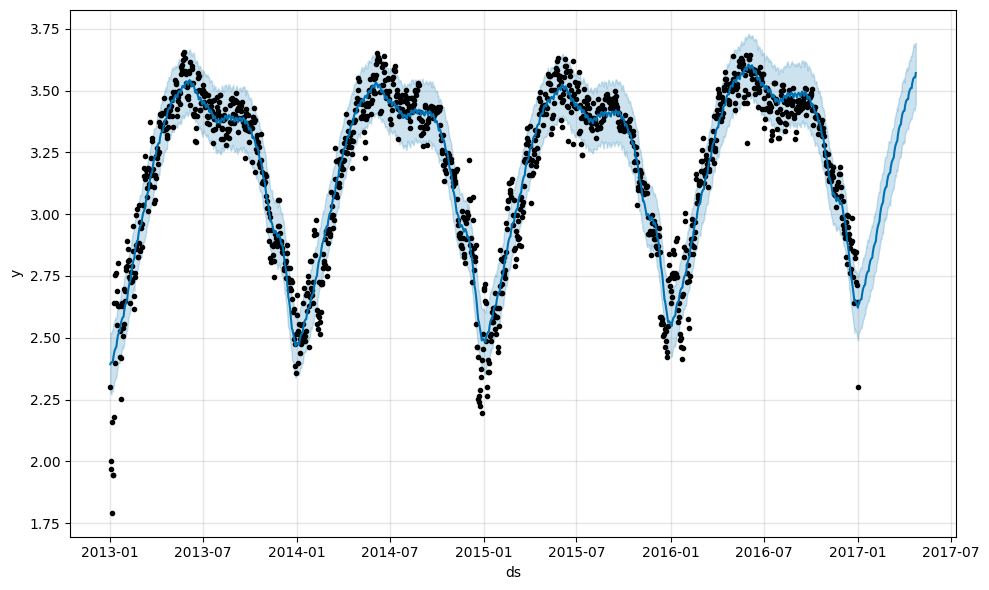

In [39]:
model.plot(forcaste_data);

### Plot Components

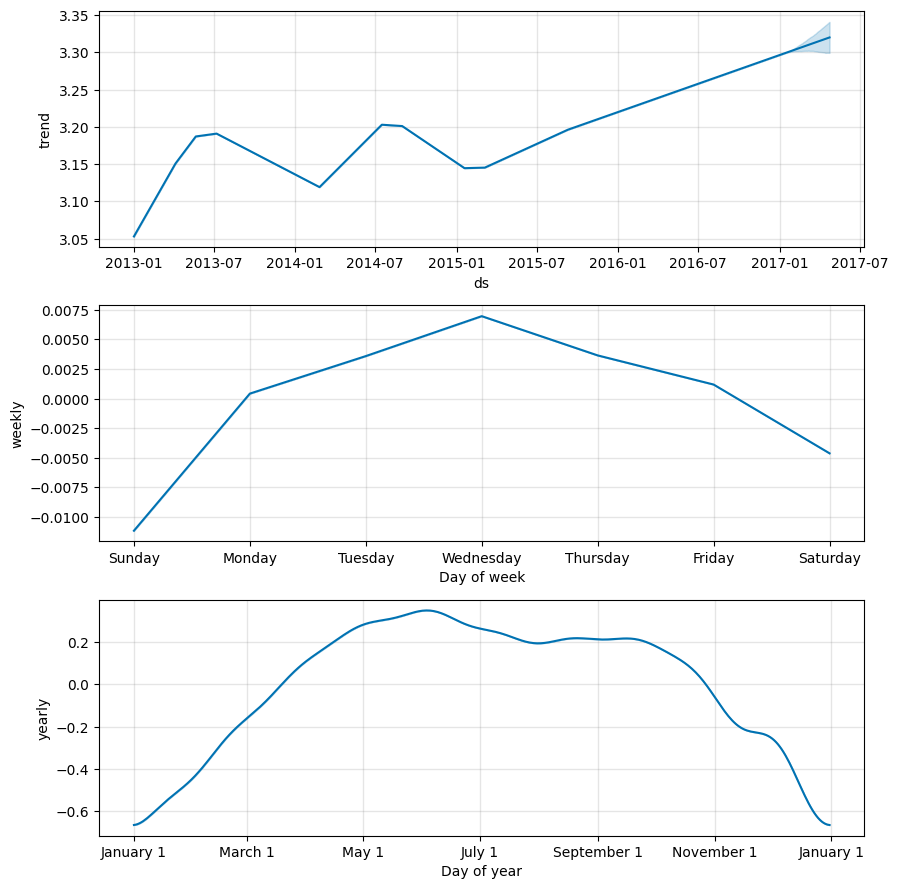

In [40]:
model.plot_components(prediction);

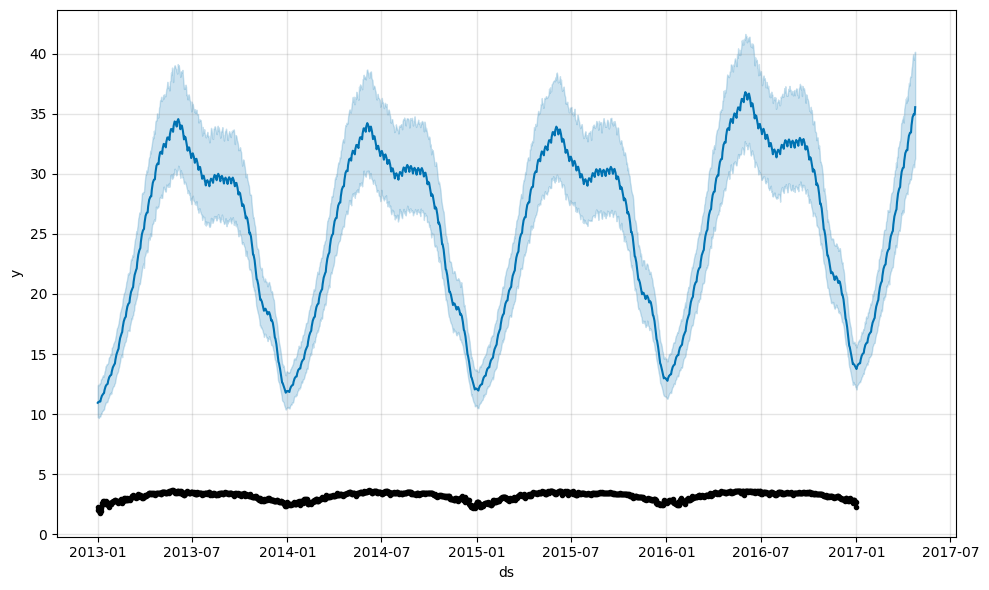

In [41]:
# Inverse Transformation on Log Data
forcaste_data_original = forcaste_data.copy()
forcaste_data_original['yhat'] = np.exp(forcaste_data_original['yhat'])
forcaste_data_original['yhat_lower'] = np.exp(forcaste_data_original['yhat_lower'])
forcaste_data_original['yhat_upper'] = np.exp(forcaste_data_original['yhat_upper']) 

# Plot Original Data
model.plot(forcaste_data_original);

In [18]:
# New Visulization
final_df = pd.DataFrame(forcaste_data_original)

# Plot Predicted and Actual line Graph with x = dates, y = Outbound
actual_chart = go.Scatter(y = df_train['y_org'], name='Actual', line = dict(color='black'))
predict_chart = go.Scatter(y = final_df['yhat'], name='Predicted', line = dict(color='blue'))
predict_upper_limit = go.Scatter(y = final_df['yhat_upper'], name = 'Upper Limit', line = dict(color='red'))
predict_lower_limit = go.Scatter(y=final_df['yhat_lower'], name = 'Lower Limit', line = dict(color='green'))

py.plot([actual_chart, predict_chart, predict_upper_limit, predict_lower_limit])

fig = go.Figure([actual_chart, predict_chart, predict_upper_limit, predict_lower_limit])
fig.show()

'temp-plot.html'

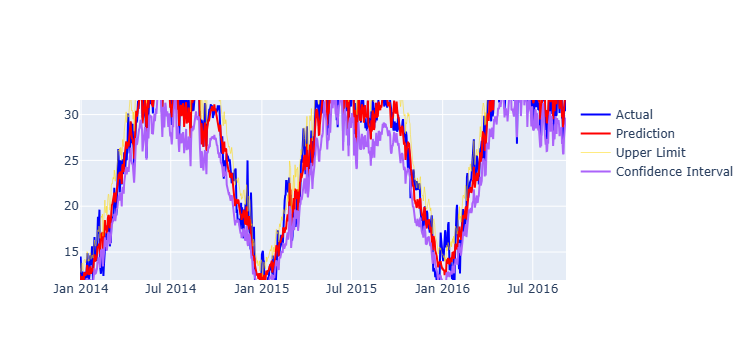

In [35]:
# Chat Gpt
Actual = go.Scatter(
    x=df_train['ds'],
    y=df_train['y_org'],
    mode='lines',
    name='Actual',
    line=dict(color='blue')
)

Predicted = go.Scatter(
    x=final_df['ds'],
    y=np.exp(final_df['yhat']),
    mode='lines',
    name='Prediction',
    line=dict(color='red')
)

Upper = go.Scatter(
    x=final_df['ds'],
    y=np.exp(final_df['yhat_upper']),
    mode='lines',
    name='Upper Limit',
    line=dict(color='gold', width=0.5),
    showlegend=True
)

Lower = go.Scatter(
    x=final_df['ds'],
    y=np.exp(final_df['yhat_lower']),
    mode='lines',
    fill='tonexty',
    name='Confidence Interval'
)

fig = go.Figure(data=[Actual, Predicted, Upper, Lower])
fig.update_layout(
    title="Actual vs Forecast",
    xaxis_title="Date",
    yaxis_title="Value",
    template="plotly_white"
)
fig.show()

### Multivarate Analysis

In [19]:
# Model Initilization
model = Prophet()

# Add Multivariate as Regressor
model.add_regressor('humidity')
model.add_regressor('wind_speed')
model.add_regressor('meanpressure')

# Fit All Data
model_fit = model.fit(df_train)
# Make Future Data Frame
future_data = model_fit.make_future_dataframe(periods=113, freq='D')

# Merge Regressor in Fututre Data
future_data = future_data.merge(
    df_train[['ds', 'humidity', 'wind_speed', 'meanpressure']],
    on='ds',
    how='left'
).ffill()

18:00:38 - cmdstanpy - INFO - Chain [1] start processing
18:00:38 - cmdstanpy - INFO - Chain [1] done processing


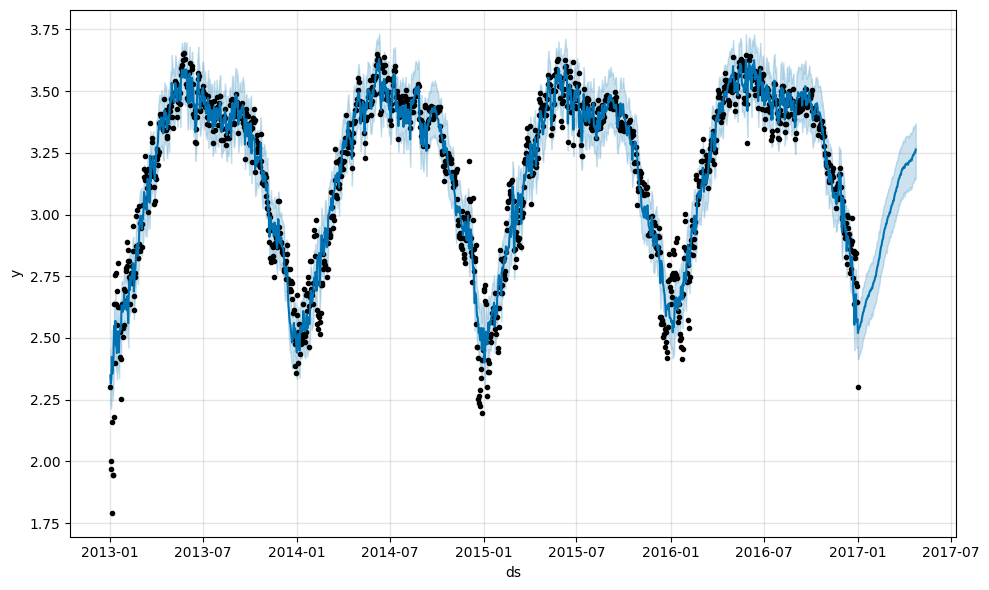

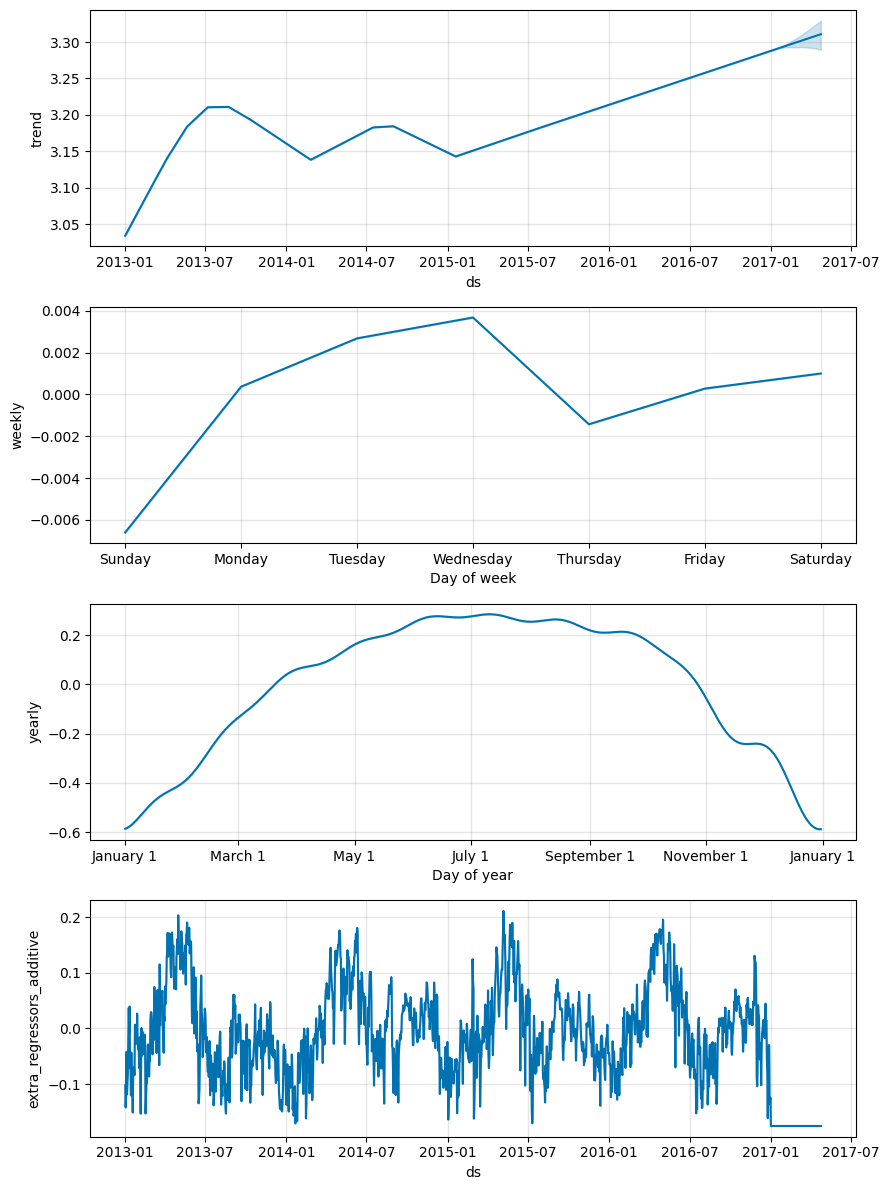

In [20]:
# Remaining Same

# Prediction by Future Data
prediction = model_fit.predict(future_data)

# Visulization
model.plot(prediction[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]);

# Componets prediction
model.plot_components(prediction);

In [21]:
# Plotly Visulization
prediction_data = prediction [['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
final_df = prediction_data.copy() 

Actual = go.Scatter(y=df_train['y_org'], name='Actual', line=dict(color='Black'))
Predicted = go.Scatter(y=np.exp(final_df['yhat']), name='Predicted', line=dict(color='Blue'))
Upper_limit = go.Scatter(y=np.exp(final_df['yhat_upper']), name='Upper Limit', line=dict(color='Red'))
Lower_limit = go.Scatter(y=np.exp(final_df['yhat_lower']), name='Lower Limit', line=dict(color='Green'))

py.plot([Actual, Predicted, Upper_limit, Lower_limit])

'temp-plot.html'